In [1]:
import gymnasium as gym
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..")

In [2]:
from rlc.envs.fogofwar import FogGridEnv

env = FogGridEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (row={obs // env.width}, col={obs % env.width})")

Observation space: Discrete(64)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: 0  (row=0, col=0)


In [3]:
env = FogGridEnv(
    height=5,
    width=5,
    start_pos=(0, 0),
    goal_pos=(4, 4),
    obstacle_tiles=[
        (1, 1),
        (1, 2),
        (3, 3),
    ],
    trap_tiles=[
        (2, 2),
    ],
)

obs, info = env.reset()

print(obs)
print(env._agent_pos)

0
(0, 0)


In [4]:
obs, reward, terminated, truncated, info = env.step(1)

print(env._agent_pos)
print(reward)

(0, 1)
-1.0


In [5]:
obs, reward, terminated, truncated, info = env.step(1)

print(env._agent_pos)
print(reward)

(0, 2)
-1.0


In [6]:
obs, reward, terminated, truncated, info = env.step(2)

print(env._agent_pos)
print(reward)

(0, 2)
-1.0


In [7]:
env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.1,
    trap_density=0.1,
)

env.reset(seed = 41)

env.print_map()

A . . X . X . . . . X .
O . . . . . . . . . X .
. . O . . . O . . X . .
O . . . . . O X O . . .
. . . O . . . . . . O .
. O O . . . . . . . . .
X X . . . . . . . . . .
X . . . . O . . X . O .
. . . . . . . . . X . .
. . . . X . . X . X . .
. . O . . . . . . . . .
. . . . . . . . O . . G


In [11]:
# based of a randomized map with seed = 41

fixed_obstacle_tiles = [(4, 10),
 (3, 8),
 (7, 5),
 (4, 3),
 (7, 10),
 (5, 1),
 (3, 0),
 (2, 6),
 (3, 6),
 (2, 2),
 (1, 0),
 (11, 8),
 (10, 2),
 (5, 2)]

fixed_trap_tiles = [(0, 10),
 (9, 9),
 (6, 1),
 (3, 7),
 (0, 3),
 (7, 0),
 (2, 9),
 (8, 9),
 (1, 10),
 (6, 0),
 (0, 5),
 (9, 7),
 (7, 8),
 (9, 4)]


In [10]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=False,
    obstacle_tiles= fixed_obstacle_tiles,
    trap_tiles=fixed_trap_tiles,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=False,
    obstacle_tiles= fixed_obstacle_tiles,
    trap_tiles=fixed_trap_tiles,
    render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    77.7
Final greedy evaluation return:    79.0 (std 0.0)
Final evaluation success rate: 100.0%
Final mean episode length: 22.0 steps


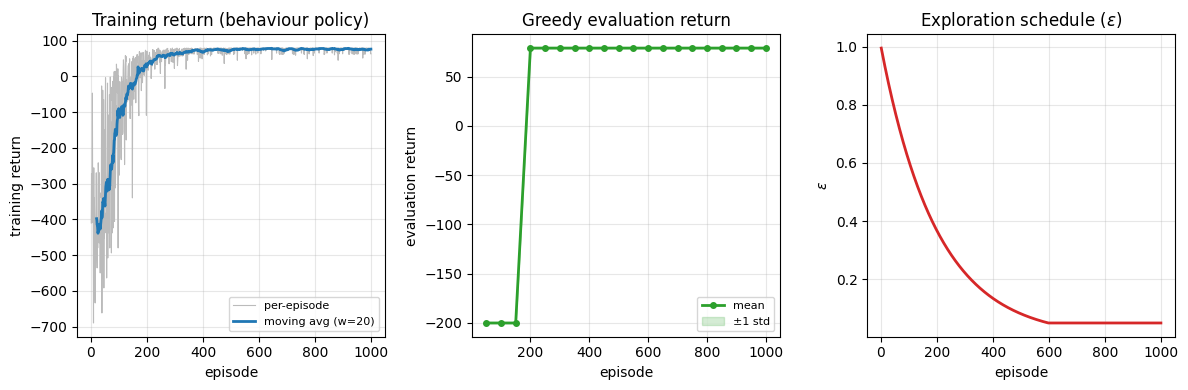

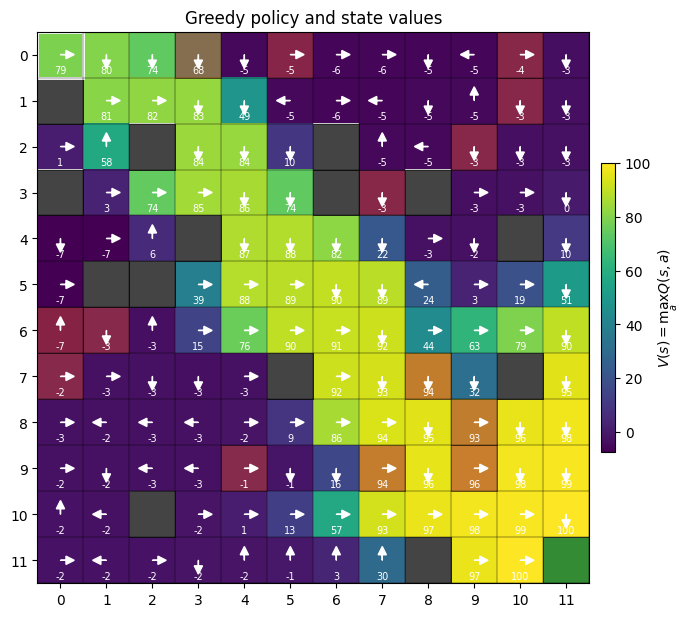

In [15]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

In [13]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed = 42
)

history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True,
    seed = 42
)


print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -69.1
Final greedy evaluation return:    -178.3 (std 87.4)
Final evaluation success rate: 13.0%
Final mean episode length: 176.9 steps


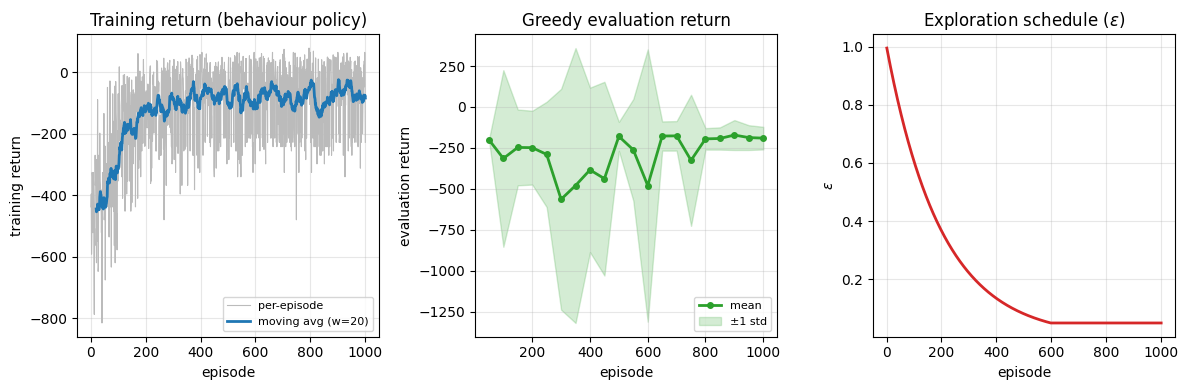

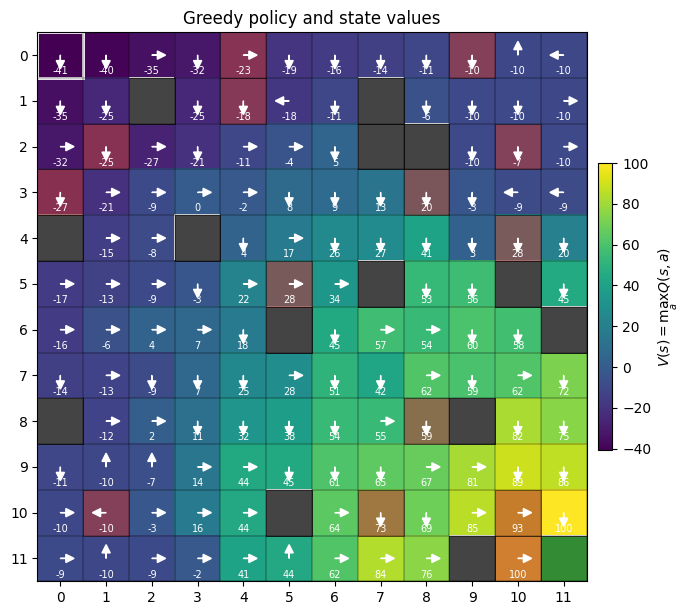

In [18]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## Second agent

In [16]:
from rlc.agents.q_learning_wlocal import LocalQLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    vision_radius=2,
    local_view= True,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    vision_radius=2,
    local_view= True,
    render_mode="rgb_array")

agent = LocalQLearningAgent(
    n_actions=train_env.action_space.n,
    alpha=0.001,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed = 42
)

history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True,
    seed = 42
)


print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -345.9
Final greedy evaluation return:    -376.3 (std 604.9)
Final evaluation success rate: 0.0%
Final mean episode length: 200.0 steps


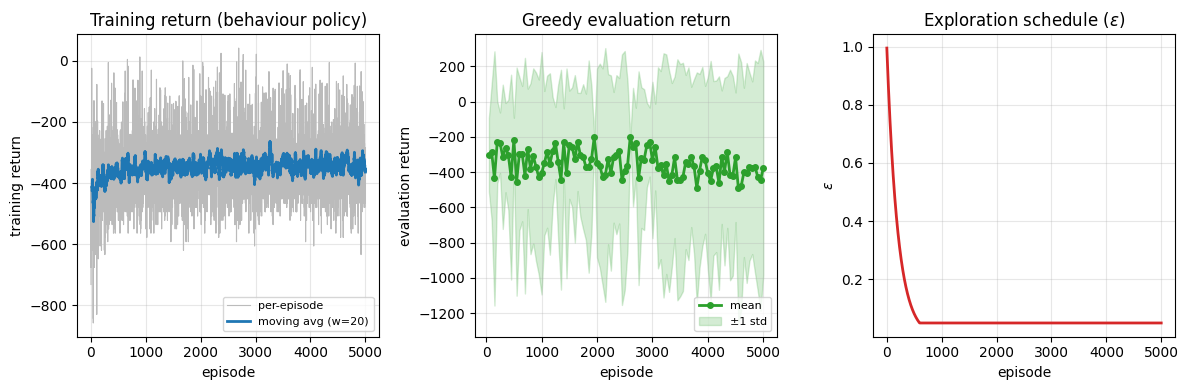

In [17]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()

In [18]:
env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.1,
    trap_density=0.1,
    vision_radius=2,
    local_view=True,
)

# Third model

In [3]:
from rlc.agents.q_learning_LFA import LFAQLearningAgent
from rlc.utils.features import LocalQuadrantFeatures
from rlc.utils.training import train

In [7]:
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.05,
    trap_density=0.03,
    vision_radius=2,
    local_view=True,
    render_mode="rgb_array",
)

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.05,
    trap_density=0.03,
    vision_radius=2,
    local_view=True,
    render_mode="rgb_array",
)

features = LocalQuadrantFeatures(
    height=train_env.height,
    width=train_env.width,
    vision_radius=2,
    exp_decay=1.0,
)

agent = LFAQLearningAgent(
    n_actions=train_env.action_space.n,
    feature_extractor=features,
    alpha=0.001,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.10,
    epsilon_decay=0.999,
    seed=42
)


history = train(
    agent,
    train_env,
    n_episodes=5000,
    max_steps_per_episode=200,
    eval_every=100,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    seed=42,
    progress=True,
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")
print("Weight matrix size:", agent.weights.shape)
print("Weight norm:", np.linalg.norm(agent.weights))
print(f"Final evaluation success rate: " f"{history.eval_success_rate[-1] * 100:.1f}%")
print(f"Final mean episode length: " f"{history.eval_mean_len[-1]:.1f} steps")

train_succ_rate = np.mean(history.eps_successess)

print(f"Training success rate: " f"{train_succ_rate * 100:.1f}%")

Training:   0%|          | 0/5000 [00:00<?, ?ep/s]

Final epsilon:                     0.100
Mean return, last 50 train eps:    -186.0
Final greedy evaluation return:    -213.2 (std 115.5)
Weight matrix size: (4, 30)
Weight norm: 79.35232078871246
Final evaluation success rate: 1.0%
Final mean episode length: 198.2 steps
Training success rate: 79.5%


In [8]:
positions = []

obs, _ = eval_env.reset(seed=42)

for _ in range(200):
    positions.append(eval_env._agent_pos)

    action = agent.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, _ = eval_env.step(action)

    if terminated or truncated:
        break

print(positions)

[(0, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0), (1, 0), (2, 0),

In [20]:
from collections import Counter

Counter(positions)

Counter({(1, 0): 100, (2, 0): 99, (0, 0): 1})

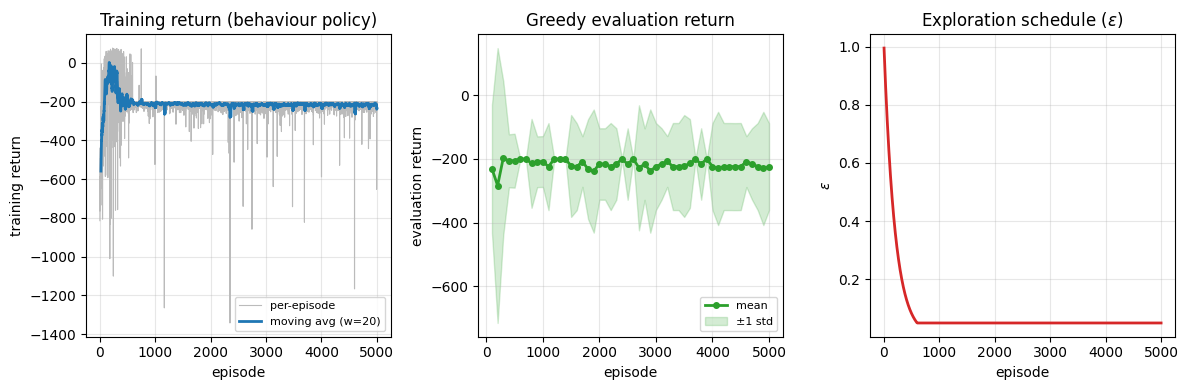

In [16]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()

LFA